# Day 11 – Walk-Forward Validation (EURUSD)

## Objective
Test whether optimized strategy parameters remain effective on unseen data.

## Goal
Reduce the risk of overfitting by separating parameter selection from performance evaluation.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [4]:
#Split Test and Train Dataset
split_index = int(len(df) * 0.7)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 3500
Test size: 1500


In [5]:
#Define Parameter grind
short_windows = [10, 20, 30]
long_windows = [50, 100, 150]

In [6]:
#Optimize on the training Data Only
train_results = []

for short in short_windows:
    for long in long_windows:
        if short >= long:
            continue
        
        temp = train.copy()
        
        temp["SMA_short"] = temp["close"].rolling(short).mean()
        temp["SMA_long"] = temp["close"].rolling(long).mean()
        
        temp["signal"] = np.where(temp["SMA_short"] > temp["SMA_long"], 1, 0)
        temp["position"] = temp["signal"].shift(1)
        temp["strategy_return"] = temp["position"] * temp["simple_return"]
        
        equity = (1 + temp["strategy_return"]).cumprod()
        
        annual_return = temp["strategy_return"].mean() * 252
        annual_vol = temp["strategy_return"].std() * np.sqrt(252)
        sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan
        
        train_results.append({
            "Short Window": short,
            "Long Window": long,
            "Train Return": equity.iloc[-1] - 1,
            "Train Sharpe": sharpe
        })

In [7]:
#View Training Optimization Table
train_results_df = pd.DataFrame(train_results)
train_results_df

,Short Window,Long Window,Train Return,Train Sharpe
0,10,50,0.030995,0.066445
1,10,100,-0.086043,-0.076402
2,10,150,0.025492,0.060245
3,20,50,-0.102123,-0.096158
4,20,100,0.072677,0.113007
5,20,150,0.042525,0.080472
6,30,50,-0.041968,-0.020705
7,30,100,0.089768,0.133371
8,30,150,0.207465,0.264522


In [10]:
#Select Best Parameters from Training Data
best_params = train_results_df.sort_values(by="Train Sharpe", ascending=False).iloc[0]
best_params

Short Window     30.000000
Long Window     150.000000
Train Return      0.207465
Train Sharpe      0.264522
Name: 8, dtype: float64

In [11]:
#Extract the best Value
best_short = int(best_params["Short Window"])
best_long = int(best_params["Long Window"])

print("Best Short Window:", best_short)
print("Best Long Window:", best_long)

Best Short Window: 30
Best Long Window: 150


In [12]:
#Apply the Best Parameter to the Test Data
test["SMA_short"] = test["close"].rolling(best_short).mean()
test["SMA_long"] = test["close"].rolling(best_long).mean()

test["signal"] = np.where(test["SMA_short"] > test["SMA_long"], 1, 0)
test["position"] = test["signal"].shift(1)
test["strategy_return"] = test["position"] * test["simple_return"]

test["equity"] = (1 + test["strategy_return"]).cumprod()
test["buy_hold"] = (1 + test["simple_return"]).cumprod()

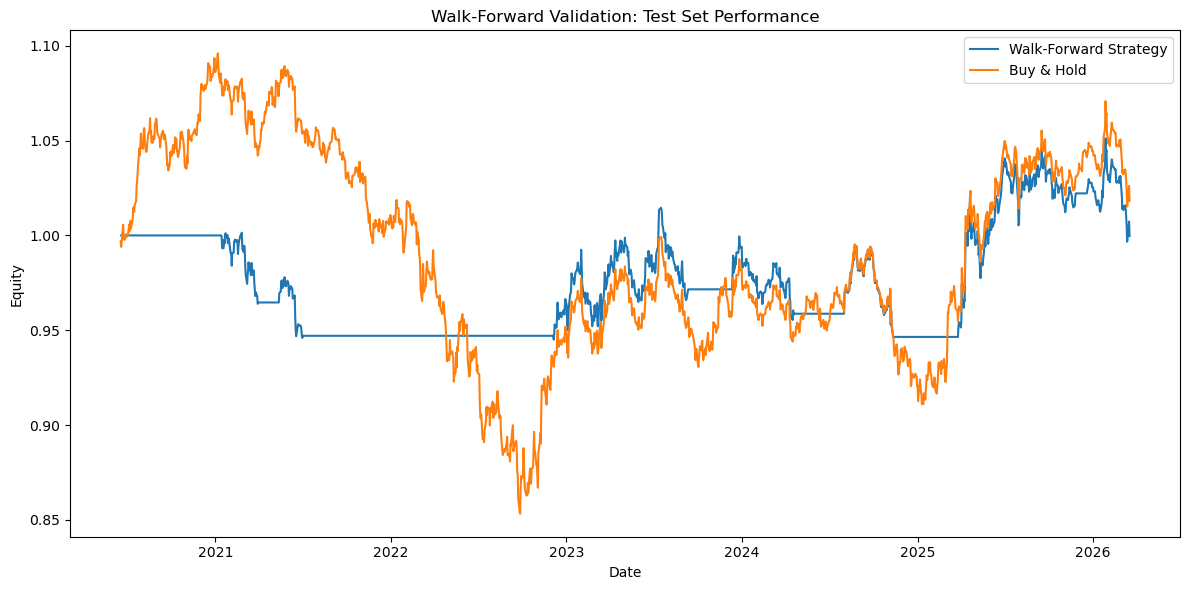

In [13]:
#Visiblity: Plot Test Performance
plt.figure(figsize=(12, 6))

plt.plot(test.index, test["equity"], label="Walk-Forward Strategy")
plt.plot(test.index, test["buy_hold"], label="Buy & Hold")

plt.title("Walk-Forward Validation: Test Set Performance")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day11_test_performance.png")
plt.show()

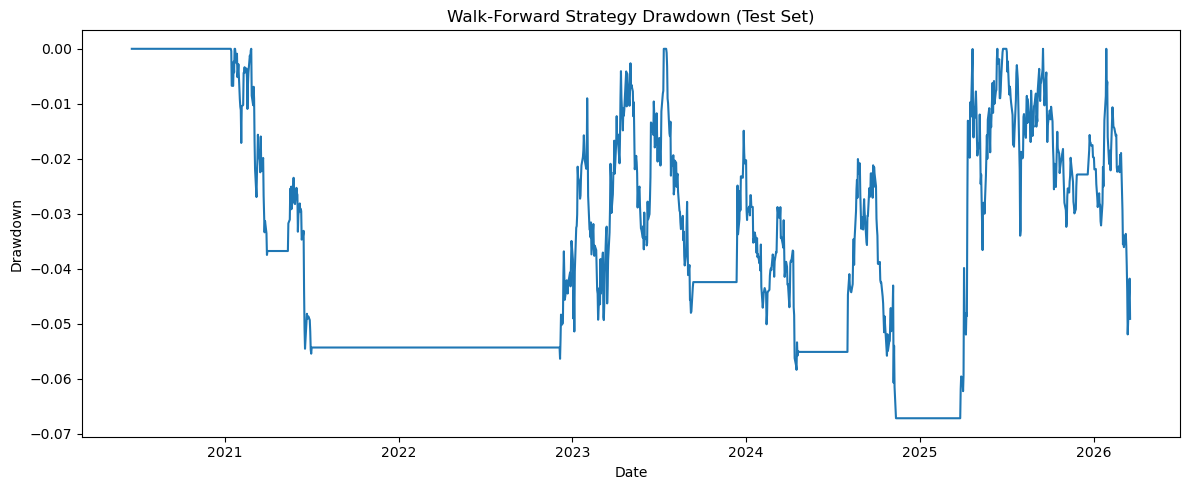

In [14]:
#Compute Drawdown on Test Set
rolling_max = test["equity"].cummax()
test["drawdown"] = (test["equity"] - rolling_max) / rolling_max

#Plot it:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test["drawdown"])

plt.title("Walk-Forward Strategy Drawdown (Test Set)")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.savefig("outputs/charts/day11_test_drawdown.png")
plt.show()

In [15]:
#Create Test Metrics
test_total_return = test["equity"].iloc[-1] - 1
test_annual_return = test["strategy_return"].mean() * 252
test_annual_vol = test["strategy_return"].std() * np.sqrt(252)
test_sharpe = test_annual_return / test_annual_vol if test_annual_vol != 0 else np.nan
test_max_dd = test["drawdown"].min()

test_metrics = pd.DataFrame({
    "Metric": [
        "Best Short Window",
        "Best Long Window",
        "Test Total Return",
        "Test Annual Return",
        "Test Volatility",
        "Test Sharpe Ratio",
        "Test Max Drawdown"
    ],
    "Value": [
        best_short,
        best_long,
        test_total_return,
        test_annual_return,
        test_annual_vol,
        test_sharpe,
        test_max_dd
    ]
})

test_metrics

,Metric,Value
0,Best Short Window,30.000000
1,Best Long Window,150.000000
2,Test Total Return,-0.000350
3,Test Annual Return,0.001122
4,Test Volatility,0.048634
5,Test Sharpe Ratio,0.023077
6,Test Max Drawdown,-0.067145


In [16]:
#Save Results
train_results_df.to_csv("outputs/tables/day11_train_optimization.csv", index=False)
test_metrics.to_csv("outputs/tables/day11_test_metrics.csv", index=False)
test.to_csv("outputs/tables/day11_test_data.csv")

## Analyst Interpretation

This project evaluates whether the strategy parameters selected from historical data remain effective when applied to new, unseen data.

The training set was used to identify the moving average combination with the strongest risk-adjusted performance. That combination was then applied to the test set, which represents a more realistic out-of-sample environment.

This is important because a strategy that performs well only on the data used to optimize it may not be reliable in practice. By separating parameter selection from evaluation, the analysis reduces the risk of overfitting.

The training optimization table shows which parameter combinations looked strongest during the historical selection phase. The test performance chart and metrics then reveal whether those “best” parameters remain useful outside the training sample.

If test performance remains stable, it suggests the strategy may have some robustness. If performance weakens significantly, it indicates that the optimized parameters may have been too closely fitted to past data.

Overall, this project demonstrates that strong historical performance is not enough. A strategy must also prove itself on unseen data before it can be considered more reliable.

## Conclusion

Walk-forward validation is a critical step in quantitative research because it helps distinguish between genuine strategy strength and historical overfitting.

This project shows that parameter optimization should always be followed by out-of-sample testing. The goal is not to find the best strategy for the past, but to identify settings that can remain effective in future market conditions.